# CRNN_03_Testing.ipynb

## Optical Character Recognition (OCR) Testing

This notebook performs inference using the trained Convolutional Recurrent Neural Network (CRNN) model.

Unlike the previous notebook (**CRNN_02_Training.ipynb**), which focused on training the OCR model using CTC Loss, this notebook focuses solely on predicting license plate characters from cropped plate images.

The workflow consists of:

1. Import required libraries
2. Configure the testing environment
3. Reconstruct the trained CRNN architecture
4. Load the trained model (`best_crnn.pth`)
5. Decode the CRNN predictions using CTC Greedy Decoding
6. Predict license plate text from input images
7. Evaluate the OCR performance on test images

> **Note:** The CRNN architecture and character vocabulary used in this notebook are identical to those defined in `CRNN_02_Training.ipynb` to ensure compatibility with the trained model.

# Step 1 - Import Required Libraries

This section imports all libraries required for OCR inference.

Most of these libraries are identical to those used during training in `CRNN_02_Training.ipynb`. Keeping the same environment ensures compatibility with the saved CRNN model.

In [20]:
# =====================================================
# Import Libraries
# =====================================================

import os
import random
import numpy as np

import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torchvision.transforms as transforms

import matplotlib.pyplot as plt

print("=" * 60)
print("Libraries Imported Successfully")
print("=" * 60)

Libraries Imported Successfully


# Step 2 - Configure the Testing Environment

This section defines the configuration required for OCR inference.

The settings used in this notebook are copied directly from `CRNN_02_Training.ipynb` to ensure consistency with the trained model. Using identical configurations ensures that the saved model (`best_crnn.pth`) can be loaded correctly without any mismatch.

The configuration includes:

- Device selection (CPU or GPU)
- Image dimensions
- Character vocabulary
- Number of output classes

In [21]:
# =====================================================
# Configuration
# =====================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMAGE_HEIGHT = 32
IMAGE_WIDTH = 128

print("=" * 60)
print(f"Device       : {DEVICE}")
print(f"Image Size   : {IMAGE_WIDTH} x {IMAGE_HEIGHT}")
print("=" * 60)

Device       : cuda
Image Size   : 128 x 32


# Step 3 - Define Character Vocabulary

This section defines the character vocabulary used by the CRNN model.

The vocabulary must be **identical** to the one used during training in `CRNN_02_Training.ipynb`. Each character is assigned a unique numerical index, allowing the model to convert between text labels and numerical representations.

The first index (`0`) is reserved for the **CTC blank token**, while the remaining indices represent digits and uppercase English alphabets used in Malaysian vehicle registration plates.

> **Note:** Any modification to the character vocabulary or character ordering will result in an incompatibility between the trained model (`best_crnn.pth`) and the testing notebook.

In [22]:
# =====================================================
# Character Vocabulary
# =====================================================

CHARSET = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ"

CTC_BLANK = 0

char_to_idx = {c: i + 1 for i, c in enumerate(CHARSET)}
idx_to_char = {i + 1: c for i, c in enumerate(CHARSET)}

num_classes = len(CHARSET) + 1

print("=" * 60)
print("Character Vocabulary Loaded")
print(f"Characters : {len(CHARSET)}")
print(f"Classes    : {num_classes}")
print("=" * 60)

Character Vocabulary Loaded
Characters : 36
Classes    : 37


# Step 4 - Reconstruct the CRNN Model

This section reconstructs the Convolutional Recurrent Neural Network (CRNN) architecture used during training.

The model architecture **must be identical** to the one defined in `CRNN_02_Training.ipynb`. This is necessary because the trained weights stored in `best_crnn.pth` correspond to this exact network structure.

The CRNN consists of three main components:

1. **Convolutional Neural Network (CNN)** – extracts visual features from the input license plate image.
2. **Bidirectional Long Short-Term Memory (BiLSTM)** – learns contextual relationships between sequential features.
3. **Fully Connected Layer** – predicts the probability of each character, including the CTC blank token.

> **Note:** Any modification to the network architecture will prevent the trained weights from being loaded correctly.

In [23]:
# =====================================================
# CRNN Model
# =====================================================

class CRNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        # =================================================
        # CNN Feature Extractor
        # =================================================

        self.cnn = nn.Sequential(

            # Block 1
            nn.Conv2d(
                in_channels=1,
                out_channels=64,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3
            nn.Conv2d(
                in_channels=128,
                out_channels=256,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            # Block 4
            nn.Conv2d(
                in_channels=256,
                out_channels=256,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2,1), stride=(2,1)),

            # Block 5
            nn.Conv2d(
                in_channels=256,
                out_channels=512,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            # Block 6
            nn.Conv2d(
                in_channels=512,
                out_channels=512,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=(2,1), stride=(2,1)),

            # Final Convolution
            nn.Conv2d(
                in_channels=512,
                out_channels=512,
                kernel_size=2,
                stride=1,
                padding=0
            ),
            nn.ReLU(inplace=True)
        )

        # =================================================
        # Bidirectional LSTM
        # =================================================

        self.rnn = nn.LSTM(
            input_size=512,
            hidden_size=256,
            num_layers=2,
            bidirectional=True,
            batch_first=True
        )

        # =================================================
        # Fully Connected Layer
        # =================================================

        self.fc = nn.Linear(
            in_features=512,
            out_features=num_classes
        )

    # =====================================================
    # Forward Pass
    # =====================================================

    def forward(self, x):

        # -----------------------------
        # CNN Feature Extraction
        # -----------------------------
        x = self.cnn(x)

        # Shape:
        # (Batch, Channels, Height, Width)

        batch_size, channels, height, width = x.size()

        # Height should be 1
        assert height == 1, f"Expected feature map height = 1, but got {height}"

        # Remove Height Dimension
        # (B, C, 1, W) -> (B, C, W)
        x = x.squeeze(2)

        # Rearrange for LSTM
        # (B, C, W) -> (B, W, C)
        x = x.permute(0, 2, 1)

        # -----------------------------
        # BiLSTM
        # -----------------------------
        x, _ = self.rnn(x)

        # -----------------------------
        # Character Classification
        # -----------------------------
        x = self.fc(x)

        return x


# Step 5 - Load the Trained CRNN Model

This section initializes the CRNN model using the architecture defined in the previous step and loads the trained weights from `best_crnn.pth`.

The model is then transferred to the selected computing device (CPU or GPU) and switched to evaluation mode. During evaluation, gradient computation and parameter updates are disabled, ensuring that the model performs inference only.

> **Note:** The model architecture must be identical to the one used during training; otherwise, the trained weights cannot be loaded successfully.

In [24]:
# =====================================================
# Load Trained CRNN Model
# =====================================================

model = CRNN(num_classes).to(DEVICE)

model.load_state_dict(
    torch.load(
        "best_crnn.pth",
        map_location=DEVICE
    )
)

model.eval()

print("=" * 60)
print("CRNN Model Loaded Successfully")
print(f"Device : {DEVICE}")
print("=" * 60)

CRNN Model Loaded Successfully
Device : cuda


# Step 6 - CTC Greedy Decoder

After the CRNN model produces predictions, the output consists of probability scores for each possible character at every time step rather than the final license plate text.

To convert these predictions into readable text, **Connectionist Temporal Classification (CTC) Greedy Decoding** is applied.

The decoder performs two operations:

1. **Removes consecutive duplicate characters**
2. **Removes CTC blank tokens**

For example:

| Raw Prediction | Decoded Output |
|---------------|----------------|
| A A _ B B C _ 1 1 2 | ABC12 |

where `_` represents the CTC blank token.

> **Note:** This decoder is identical to the one used in `CRNN_02_Training.ipynb` and is reused here to ensure consistency between training and inference.

In [25]:
# =====================================================
# CTC Greedy Decoder
# =====================================================

def ctc_greedy_decode(log_probs):
    """
    log_probs: Tensor of shape (T, num_classes) for a single sample
    (already log-softmaxed).
    Returns the decoded string.
    """

    pred_indices = torch.argmax(log_probs, dim=1).tolist()

    decoded_chars = []
    previous = None

    for idx in pred_indices:

        if idx != previous and idx != CTC_BLANK:
            decoded_chars.append(idx_to_char[idx])

        previous = idx

    return "".join(decoded_chars)

# Step 7 - Image Preprocessing

Before a license plate image can be passed into the CRNN model, it must undergo the same preprocessing steps used during training.

To ensure consistency between training and inference, the following operations are performed:

1. Convert the image to grayscale.
2. Resize the image while preserving its aspect ratio.
3. Pad the image to the target size (128 × 32 pixels).
4. Convert the image into a PyTorch tensor.
5. Normalize the pixel values.

> **Note:** The preprocessing procedure is adapted directly from `CRNN_02_Training.ipynb`. Maintaining identical preprocessing ensures that the trained CRNN model receives input in the same format during inference as it did during training.

In [26]:
# =====================================================
# Image Preprocessing
# =====================================================

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


def preprocess_image(image_path):

    image = Image.open(image_path).convert("L")

    width, height = image.size

    scale = min(
        IMAGE_WIDTH / width,
        IMAGE_HEIGHT / height
    )

    new_width = int(width * scale)
    new_height = int(height * scale)

    image = image.resize(
        (new_width, new_height),
        Image.BILINEAR
    )

    canvas = Image.new(
        "L",
        (IMAGE_WIDTH, IMAGE_HEIGHT),
        color=0
    )

    x_offset = (IMAGE_WIDTH - new_width) // 2
    y_offset = (IMAGE_HEIGHT - new_height) // 2

    canvas.paste(
        image,
        (x_offset, y_offset)
    )

    image = transform(canvas)

    image = image.unsqueeze(0)

    return image.to(DEVICE)

# Step 8 - Predict a License Plate

This section performs OCR inference on a single cropped license plate image.

The workflow consists of the following steps:

1. Load the input image.
2. Apply the preprocessing pipeline.
3. Pass the image through the trained CRNN model.
4. Apply the CTC Greedy Decoder.
5. Display the input image together with the predicted license plate.

This demonstrates the complete OCR inference pipeline using the trained CRNN model.

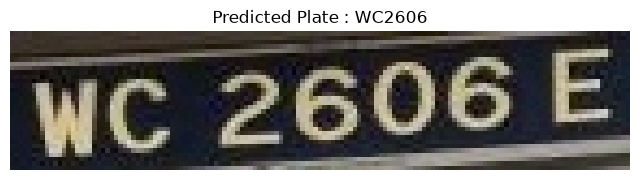

Prediction : WC2606


In [29]:
# =====================================================
# Predict License Plate
# =====================================================

# Change this to your own image
image_path = "test3.jpg"

# Preprocess image
image = preprocess_image(image_path)

# Prediction
with torch.no_grad():

    outputs = model(image)

    log_probs = outputs.log_softmax(2)

    prediction = ctc_greedy_decode(log_probs[0].cpu())

# Display image
plt.figure(figsize=(8,3))

plt.imshow(Image.open(image_path))

plt.axis("off")

plt.title(f"Predicted Plate : {prediction}")

plt.show()

print("=" * 60)
print("Prediction :", prediction)
print("=" * 60)

# Step 9 - Predict Images from the Test Dataset

To evaluate the trained CRNN model, all license plate images in the test dataset are processed automatically.

Using the test dataset ensures that the OCR model is evaluated on images that were not used during training, providing a more reliable assessment of its recognition performance.

For each image, the following steps are performed:

1. Load the test image.
2. Apply the same preprocessing used during training.
3. Perform OCR using the trained CRNN model.
4. Decode the output using CTC Best Path (Greedy) Decoding.
5. Display the image and its predicted license plate.

Testing 90 images


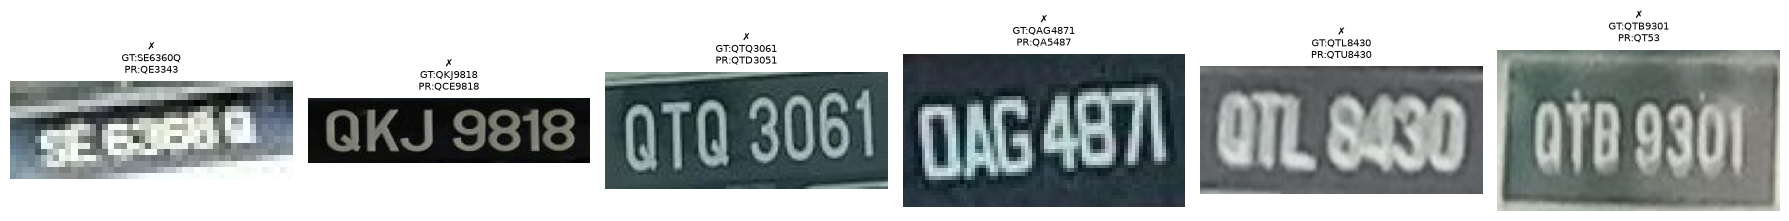

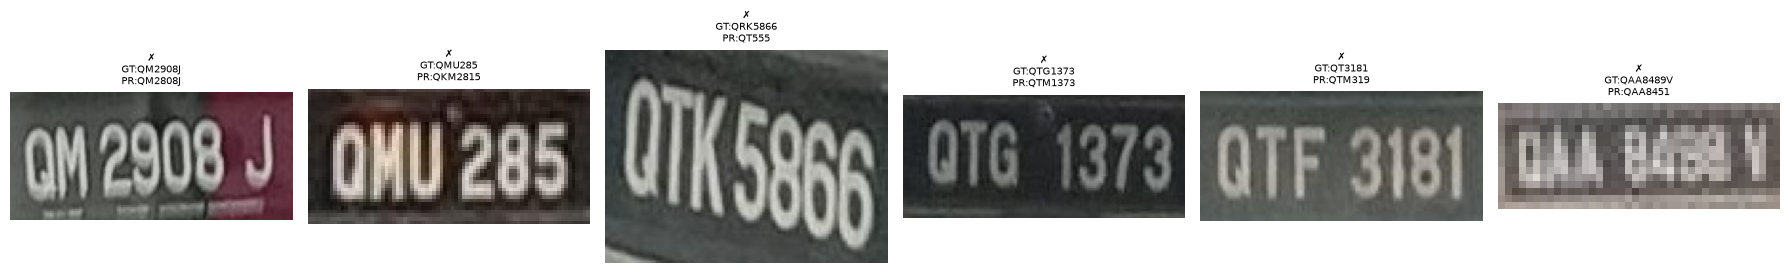

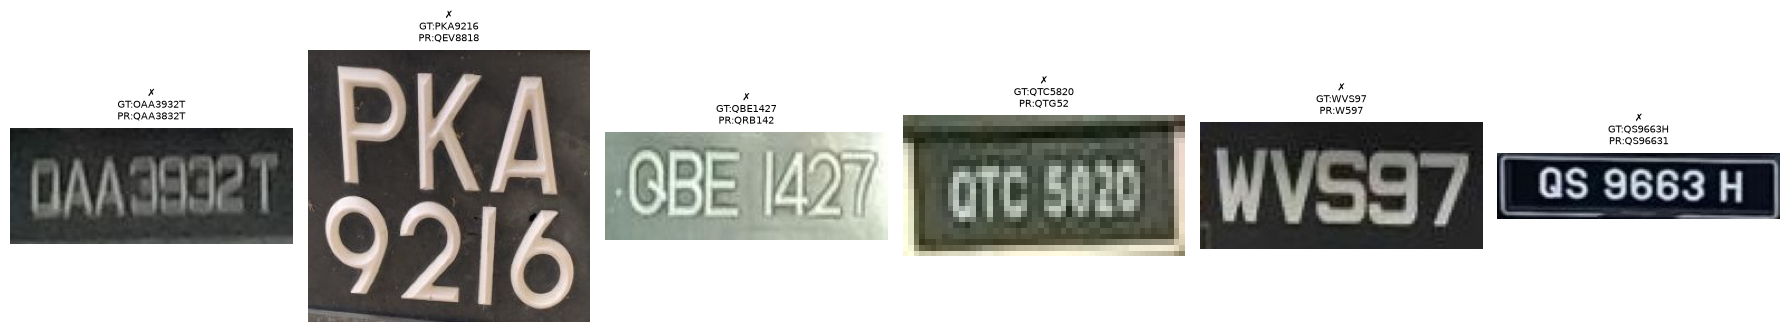

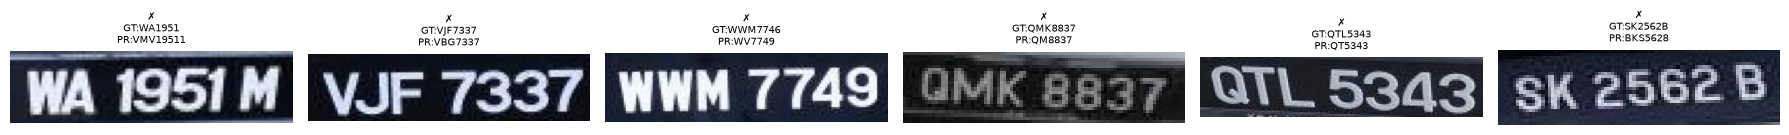

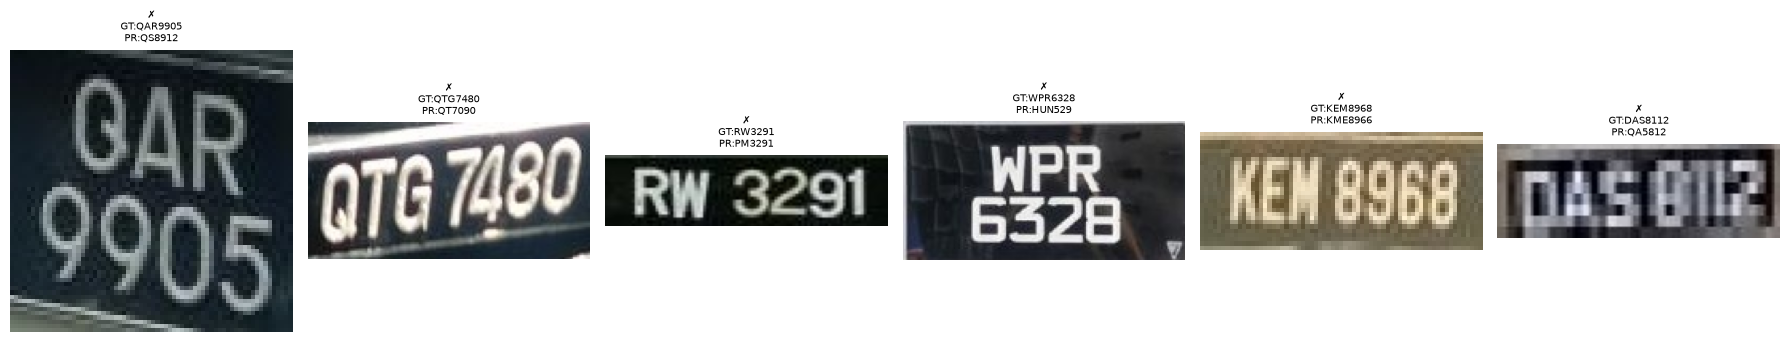

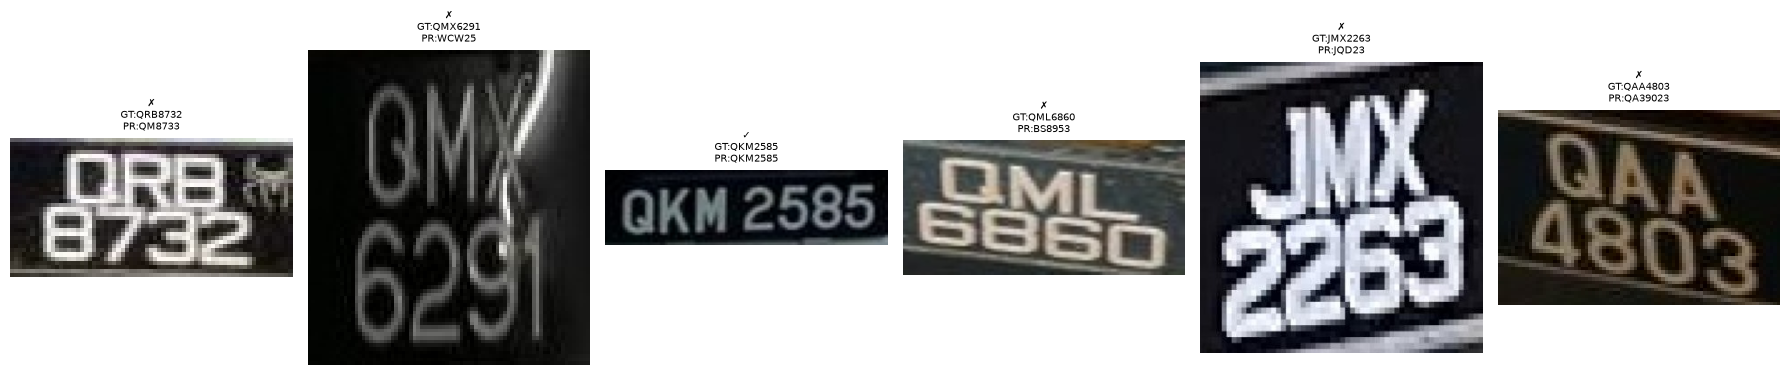

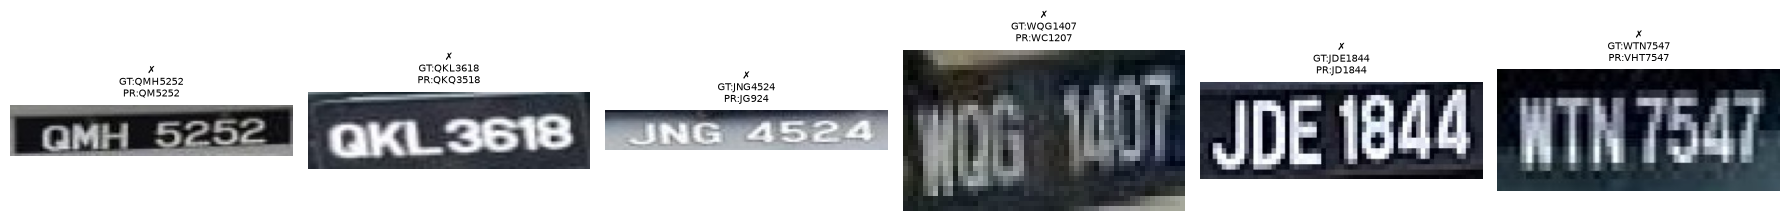

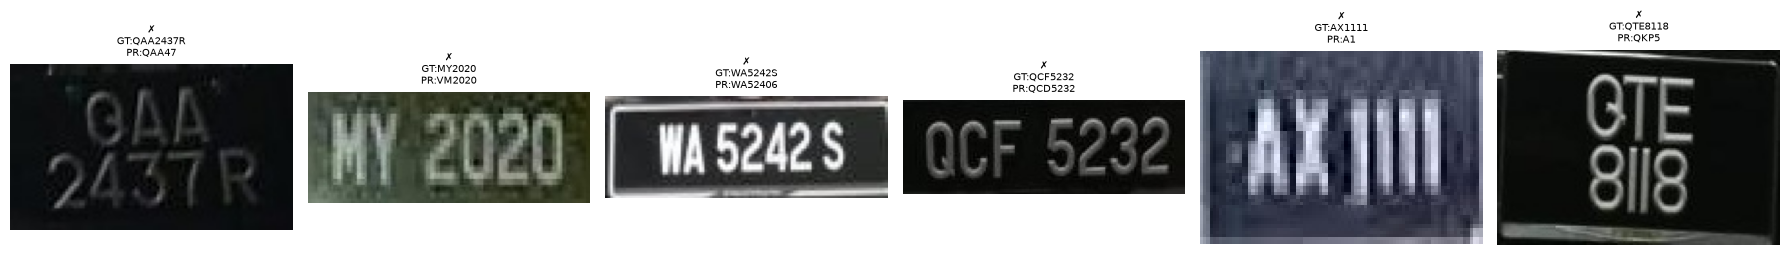

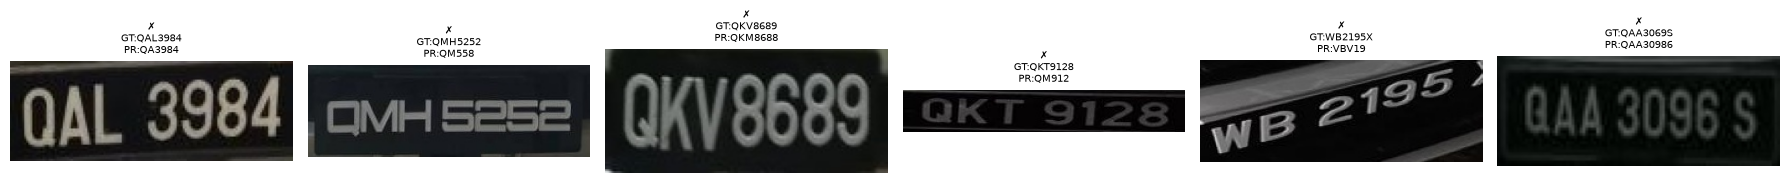

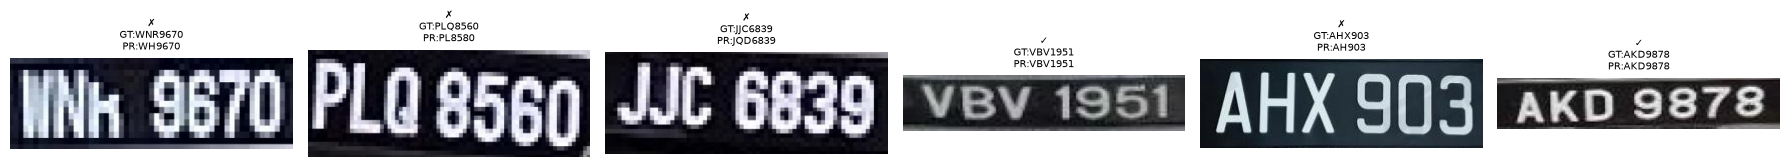

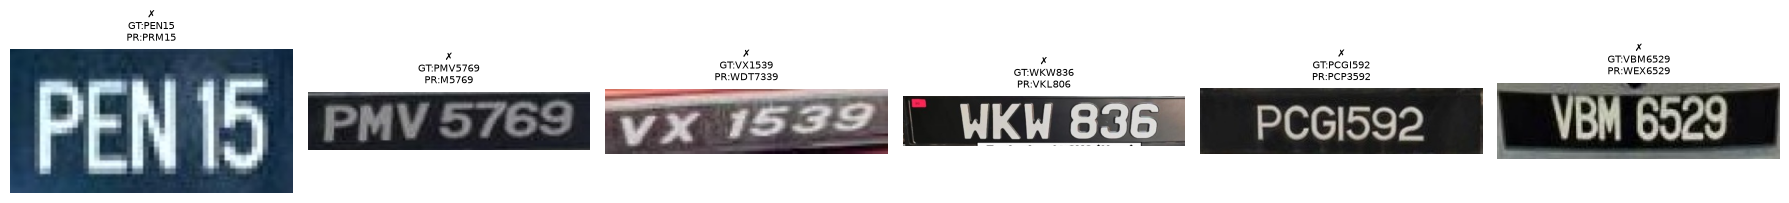

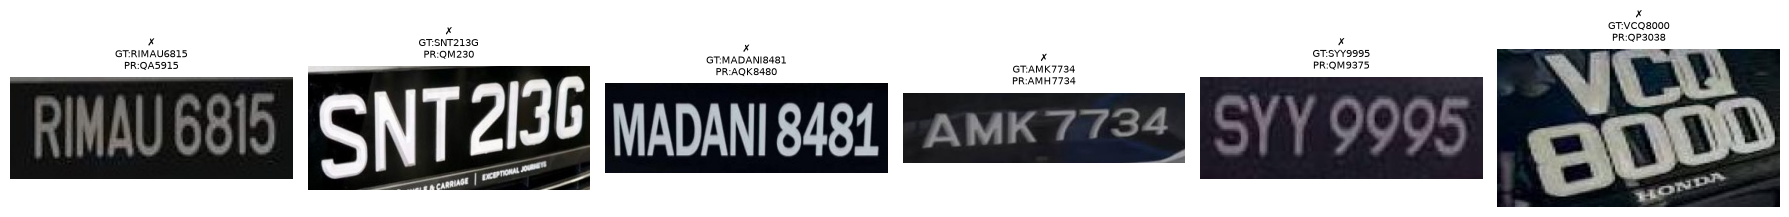

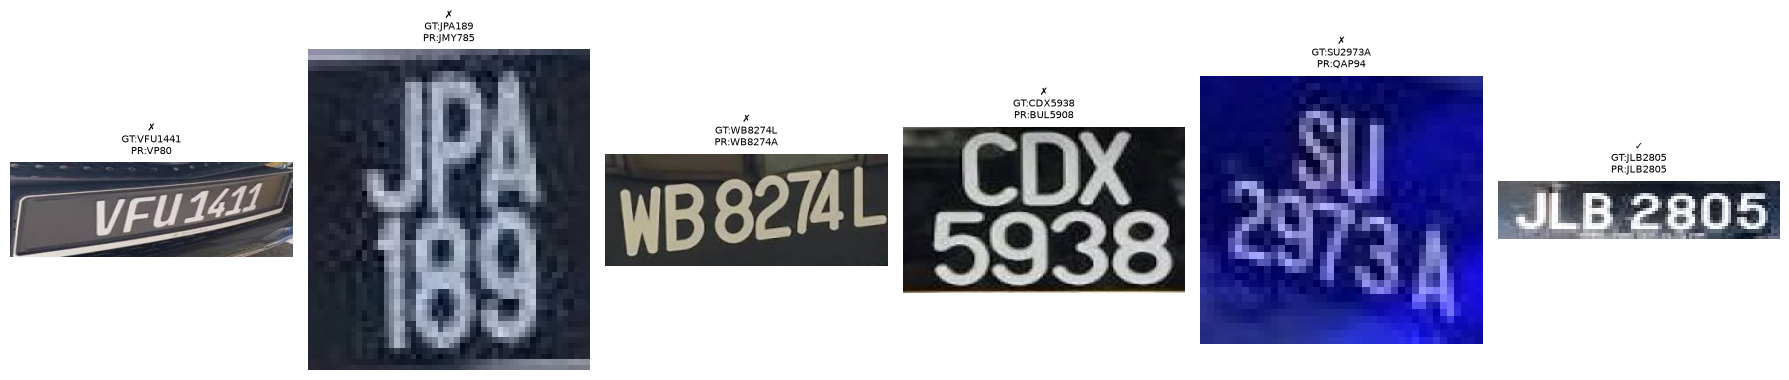

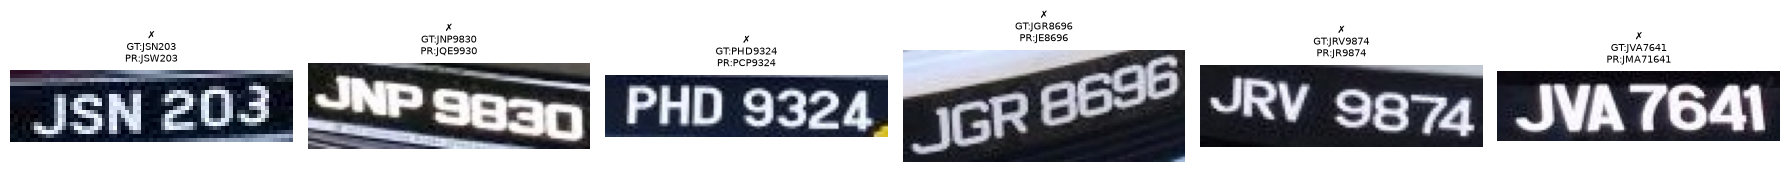

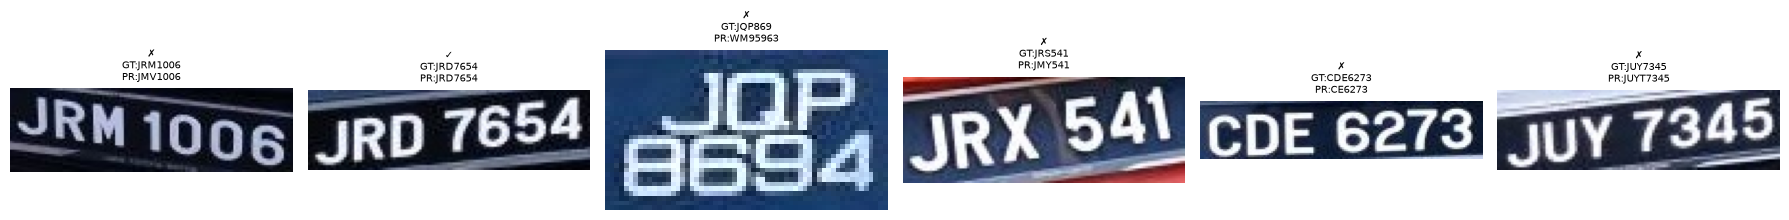


OCR EVALUATION SUMMARY
Total Images                 : 90
Correct Predictions          : 5
Incorrect Predictions        : 85
Overall OCR Accuracy         : 5.56%
Character Accuracy           : 43.88%
Recognition Rate             : 5.56%


In [35]:
# =====================================================
# OCR Evaluation on Test Dataset
# =====================================================

import os
import math
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# -----------------------------------------------------
# Dataset Paths
# -----------------------------------------------------

image_folder = "OCRDataset/test/images"
label_file = "OCRDataset/test/labels.csv"

# -----------------------------------------------------
# Load Labels
# -----------------------------------------------------

labels_df = pd.read_csv(label_file)

# Change these if your CSV uses different column names
filename_col = "filename"
label_col = "label"

ground_truth = dict(zip(labels_df[filename_col], labels_df[label_col]))

# -----------------------------------------------------
# Statistics
# -----------------------------------------------------

total_images = 0
correct_predictions = 0
incorrect_predictions = 0

total_characters = 0
correct_characters = 0

images_per_row = 6

image_files = sorted([
    f for f in os.listdir(image_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
])

print("=" * 70)
print(f"Testing {len(image_files)} images")
print("=" * 70)

# -----------------------------------------------------
# Predict
# -----------------------------------------------------

for start in range(0, len(image_files), images_per_row):

    batch = image_files[start:start+images_per_row]

    fig, axes = plt.subplots(1, len(batch), figsize=(18,4))

    if len(batch) == 1:
        axes = [axes]

    for ax, filename in zip(axes, batch):

        image_path = os.path.join(image_folder, filename)

        image = preprocess_image(image_path)

        with torch.no_grad():

            outputs = model(image)

            log_probs = outputs.log_softmax(2)

            prediction = ctc_greedy_decode(log_probs[0].cpu())

        gt = ground_truth.get(filename, "N/A")

        # Plate accuracy
        if prediction == gt:
            correct_predictions += 1
            status = "✓"
        else:
            incorrect_predictions += 1
            status = "✗"

        total_images += 1

        # Character accuracy
        max_len = max(len(gt), len(prediction))

        total_characters += max_len

        for i in range(max_len):

            gt_char = gt[i] if i < len(gt) else ""

            pred_char = prediction[i] if i < len(prediction) else ""

            if gt_char == pred_char:
                correct_characters += 1

        img = Image.open(image_path)

        ax.imshow(img)

        ax.set_title(
            f"{status}\nGT:{gt}\nPR:{prediction}",
            fontsize=7
        )

        ax.axis("off")

    plt.tight_layout()
    plt.show()

# -----------------------------------------------------
# Final Statistics
# -----------------------------------------------------

overall_accuracy = (correct_predictions / total_images) * 100

character_accuracy = (correct_characters / total_characters) * 100

recognition_rate = overall_accuracy

print("\n" + "="*70)
print("OCR EVALUATION SUMMARY")
print("="*70)

print(f"Total Images                 : {total_images}")
print(f"Correct Predictions          : {correct_predictions}")
print(f"Incorrect Predictions        : {incorrect_predictions}")
print(f"Overall OCR Accuracy         : {overall_accuracy:.2f}%")
print(f"Character Accuracy           : {character_accuracy:.2f}%")
print(f"Recognition Rate             : {recognition_rate:.2f}%")

print("="*70)